**IMPORTING THE LIBRARIES**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
dengue_dataset = pd.read_csv('/content/Dengue_Dataset_1.csv')

**Showing Rows, Columns and Shape of Dataset:**

In [ ]:
dengue_dataset.head()

,Age,Sex,Work,BpSys,Bpdias,Pulse,Cough,Fever,LLBplatelet,Headache,Muscle pain,Bleeding,Skinrash,Vomiting,Diarrhoea,IgG,IgM,Fatigue,Rapid breathing,NS1
0,32,1,2,120,80,83,0,0,0.0,0,1,0.0,0,0.0,0,0,0,1,0,0
1,28,1,1,110,80,70,1,1,0.0,1,1,0.0,0,1.0,1,0,0,1,0,0
2,30,1,1,110,70,75,0,0,0.0,0,1,0.0,0,0.0,0,0,0,0,0,0
3,2,1,0,110,80,90,0,1,0.0,0,0,0.0,0,1.0,0,0,0,1,1,0
4,22,1,1,140,100,77,0,0,0.0,1,1,0.0,0,1.0,1,0,0,1,1,0


In [ ]:
dengue_dataset

,Age,Sex,Work,BpSys,Bpdias,Pulse,Cough,Fever,LLBplatelet,Headache,Muscle pain,Bleeding,Skinrash,Vomiting,Diarrhoea,IgG,IgM,Fatigue,Rapid breathing,NS1
0,32,1,2,120,80,83,0,0,0.0,0,1,0.0,0,0.0,0,0,0,1,0,0
1,28,1,1,110,80,70,1,1,0.0,1,1,0.0,0,1.0,1,0,0,1,0,0
2,30,1,1,110,70,75,0,0,0.0,0,1,0.0,0,0.0,0,0,0,0,0,0
3,2,1,0,110,80,90,0,1,0.0,0,0,0.0,0,1.0,0,0,0,1,1,0
4,22,1,1,140,100,77,0,0,0.0,1,1,0.0,0,1.0,1,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
303,85,0,0,100,80,62,0,0,0.0,0,1,0.0,0,0.0,0,1,1,1,1,1
304,75,1,0,110,70,50,0,0,1.0,0,1,0.0,1,1.0,1,1,1,1,1,1
305,55,1,0,150,100,84,0,0,2.0,1,1,0.0,1,0.0,1,1,1,1,1,1
306,75,1,0,150,100,72,0,1,1.0,0,1,NaN,1,0.0,1,1,1,1,1,1


In [ ]:
dengue_dataset.tail()

,Age,Sex,Work,BpSys,Bpdias,Pulse,Cough,Fever,LLBplatelet,Headache,Muscle pain,Bleeding,Skinrash,Vomiting,Diarrhoea,IgG,IgM,Fatigue,Rapid breathing,NS1
303,85,0,0,100,80,62,0,0,0.0,0,1,0.0,0,0.0,0,1,1,1,1,1
304,75,1,0,110,70,50,0,0,1.0,0,1,0.0,1,1.0,1,1,1,1,1,1
305,55,1,0,150,100,84,0,0,2.0,1,1,0.0,1,0.0,1,1,1,1,1,1
306,75,1,0,150,100,72,0,1,1.0,0,1,NaN,1,0.0,1,1,1,1,1,1
307,80,1,0,110,80,82,0,0,1.0,0,1,0.0,1,1.0,1,1,1,1,1,1


In [ ]:
print(dengue_dataset.columns)

Index(['Age', ' Sex', 'Work', 'BpSys', 'Bpdias', 'Pulse', 'Cough', 'Fever',
       'LLBplatelet', 'Headache', 'Muscle pain', 'Bleeding ', 'Skinrash',
       'Vomiting ', 'Diarrhoea ', 'IgG', 'IgM', 'Fatigue', 'Rapid breathing ',
       'NS1'],
      dtype='object')


In [ ]:
dengue_dataset.shape

(308, 20)

**Shows Number of Null Values present among attributes/columns of the Initial Dataset:**

In [ ]:
dengue_dataset.isnull().sum()

Age                  0
 Sex                 0
Work                 0
BpSys                0
Bpdias               0
Pulse                0
Cough                0
Fever                0
LLBplatelet          7
Headache             0
Muscle pain          0
Bleeding            11
Skinrash             0
Vomiting            13
Diarrhoea            0
IgG                  0
IgM                  0
Fatigue              0
Rapid breathing      0
NS1                  0
dtype: int64

In [ ]:

missing_values = dengue_dataset.isnull()

missing_counts = missing_values.sum()

print("Columns with missing values:")
print(missing_counts[missing_counts > 0])


Columns with missing values:
LLBplatelet     7
Bleeding       11
Vomiting       13
dtype: int64


**Visualization of all missing values with a Heatmap**

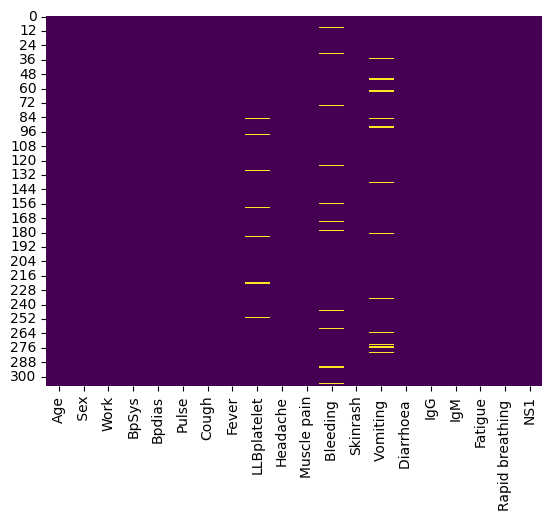

In [ ]:
sns.heatmap(missing_values, cbar=False, cmap='viridis', linecolor = 'white')
plt.show()

**Visualization of missing values of LLBplatelet**

<ipython-input-77-d3b882d4654b>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dengue_dataset['LLBplatelet'])


<Axes: xlabel='LLBplatelet', ylabel='Density'>

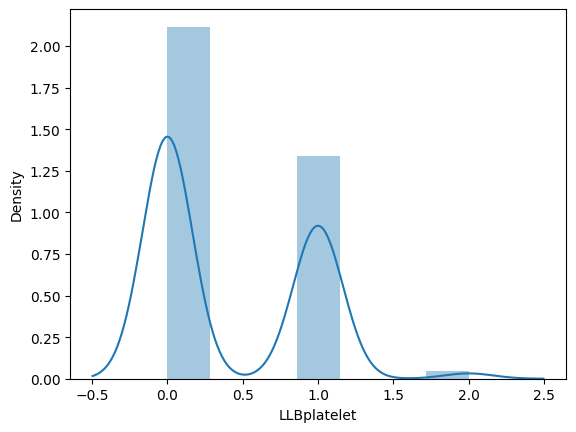

In [ ]:
sns.distplot(dengue_dataset['LLBplatelet'])


**Visualization of missing values of Bleeding**

<ipython-input-78-a6e297c5b8b6>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dengue_dataset['Bleeding '])


<Axes: xlabel='Bleeding ', ylabel='Density'>

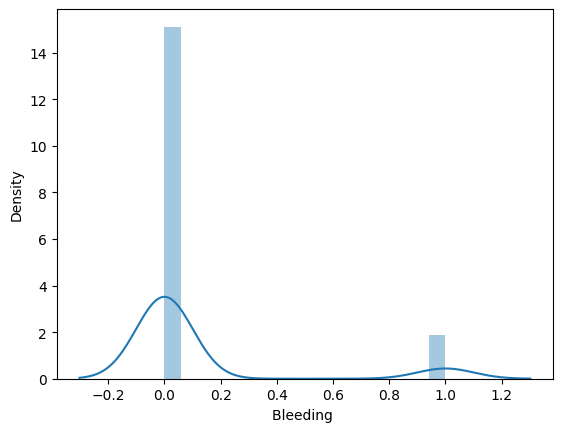

In [ ]:
sns.distplot(dengue_dataset['Bleeding '])

**Visualization of missing values of Vomiting**

<ipython-input-79-86d1cb48a39c>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dengue_dataset['Vomiting '])


<Axes: xlabel='Vomiting ', ylabel='Density'>

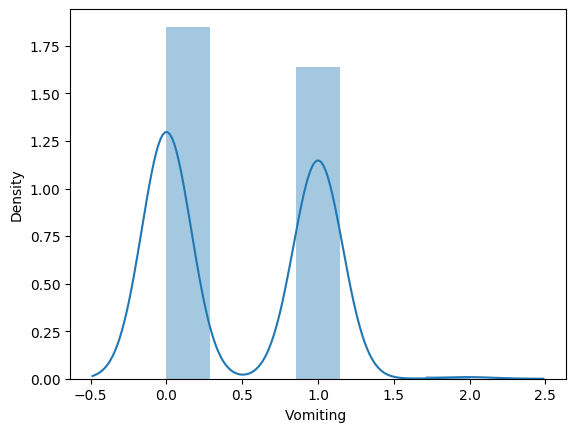

In [ ]:
sns.distplot(dengue_dataset['Vomiting '])


**HANDLING MISSING VALUES**

In [ ]:
# Check for missing values
missing_values = dengue_dataset.isnull()

# Count missing values for each column
missing_counts = missing_values.sum()

dengue_dataset.fillna(dengue_dataset.mean(), inplace=True)

In [ ]:
# Display columns with missing values and their counts
print("Columns with missing values:")
print(missing_counts[missing_counts > 0])

Columns with missing values:
LLBplatelet     7
Bleeding       11
Vomiting       13
dtype: int64


In [ ]:
dengue_dataset.isnull().sum()

Age                 0
 Sex                0
Work                0
BpSys               0
Bpdias              0
Pulse               0
Cough               0
Fever               0
LLBplatelet         0
Headache            0
Muscle pain         0
Bleeding            0
Skinrash            0
Vomiting            0
Diarrhoea           0
IgG                 0
IgM                 0
Fatigue             0
Rapid breathing     0
NS1                 0
dtype: int64

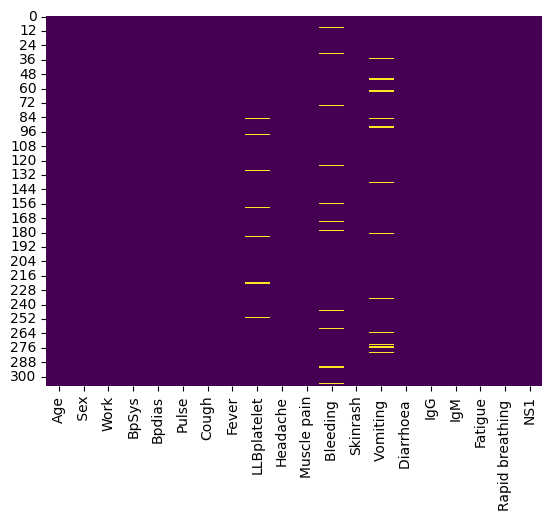

In [ ]:
sns.heatmap(missing_values, cbar=False, cmap='viridis', linecolor = 'white')
plt.show()

**SPLITTING THE DATA INTO TRAINING DATA & TESTING DATA**

In [ ]:
X = dengue_dataset.drop(columns = 'NS1', axis=1)
Y = dengue_dataset['NS1']

In [ ]:
print(X)

     Age   Sex  Work  BpSys  Bpdias  Pulse  Cough  Fever  LLBplatelet  \
0     32     1     2    120      80     83      0      0          0.0   
1     28     1     1    110      80     70      1      1          0.0   
2     30     1     1    110      70     75      0      0          0.0   
3      2     1     0    110      80     90      0      1          0.0   
4     22     1     1    140     100     77      0      0          0.0   
..   ...   ...   ...    ...     ...    ...    ...    ...          ...   
303   85     0     0    100      80     62      0      0          0.0   
304   75     1     0    110      70     50      0      0          1.0   
305   55     1     0    150     100     84      0      0          2.0   
306   75     1     0    150     100     72      0      1          1.0   
307   80     1     0    110      80     82      0      0          1.0   

     Headache  Muscle pain  Bleeding   Skinrash  Vomiting   Diarrhoea   IgG  \
0           0            1   0.000000       

In [ ]:
print(Y)

0      0
1      0
2      0
3      0
4      0
      ..
303    1
304    1
305    1
306    1
307    1
Name: NS1, Length: 308, dtype: int64


In [ ]:
dengue_dataset['NS1'].value_counts()

1    205
0    103
Name: NS1, dtype: int64

**1 --> Dengue Positive;  0 --> Dengue Negative**

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=3)

In [ ]:
print(X.shape, X_train.shape, X_test.shape)

(308, 19) (215, 19) (93, 19)


In [ ]:
print(Y.shape, Y_train.shape, Y_test.shape)

(308,) (215,) (93,)


**DATA VISUALIZATION**

**Distribution of results**

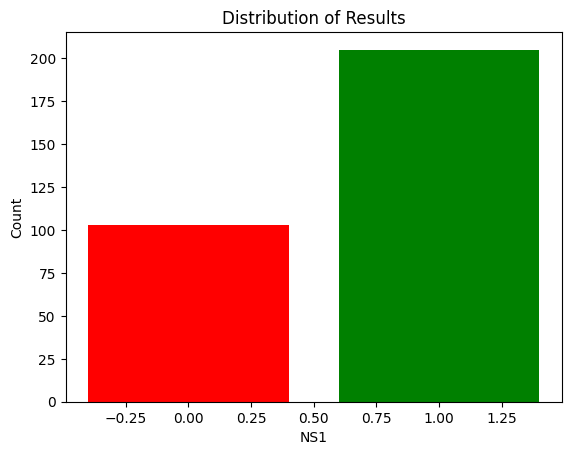

In [ ]:
# Count the occurrences of each result
result_counts = dengue_dataset['NS1'].value_counts()

# Plot the bar chart
plt.bar(result_counts.index, result_counts.values, color=['green', 'red'])
plt.xlabel('NS1')
plt.ylabel('Count')
plt.title('Distribution of Results')
plt.show()


**Heatmap**

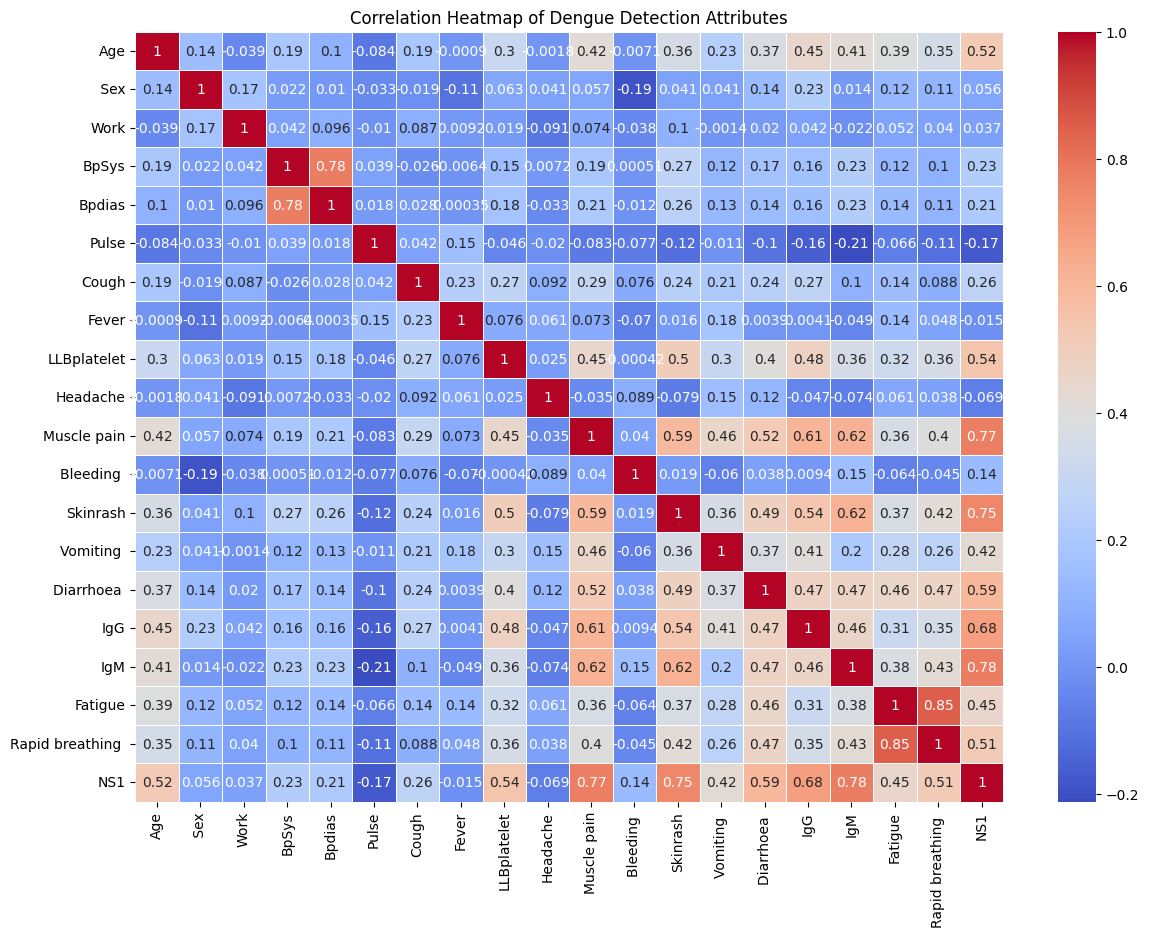

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



attributes = ['Age', ' Sex', 'Work', 'BpSys', 'Bpdias', 'Pulse', 'Cough', 'Fever',
       'LLBplatelet', 'Headache', 'Muscle pain', 'Bleeding ', 'Skinrash',
       'Vomiting ', 'Diarrhoea ', 'IgG', 'IgM', 'Fatigue', 'Rapid breathing ',
       'NS1']

# Select the 21 attributes from the dataset
selected_data = dengue_dataset[attributes]

# Calculate the correlation matrix
correlation_matrix = selected_data.corr()

# Create a heatmap
plt.figure(figsize=(14, 10))
heatmap = sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=.5)
plt.title('Correlation Heatmap of Dengue Detection Attributes')
plt.show()

**Count plot for Categorical binary value**

In [ ]:
# Python Code:
# Assuming 'categorical_binary' is a list of categorical features with binary values
categorical_binary = [' Sex','Cough','LLBplatelet','Headache','Bleeding ','IgG', 'IgM', 'Fatigue','Rapid breathing ','NS1']


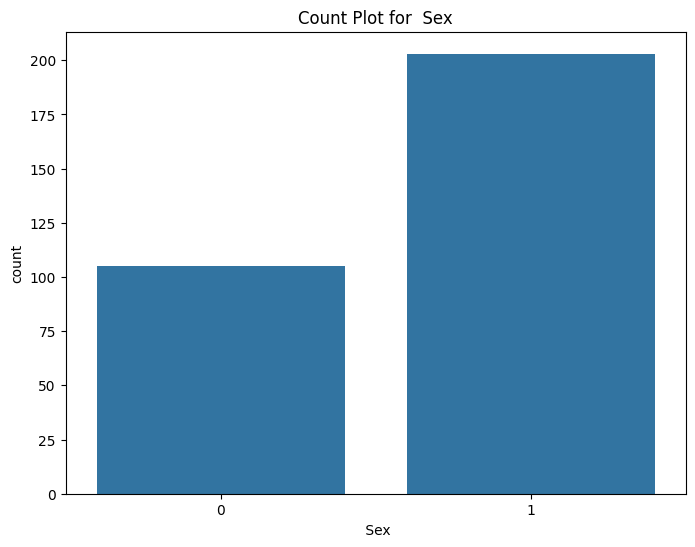

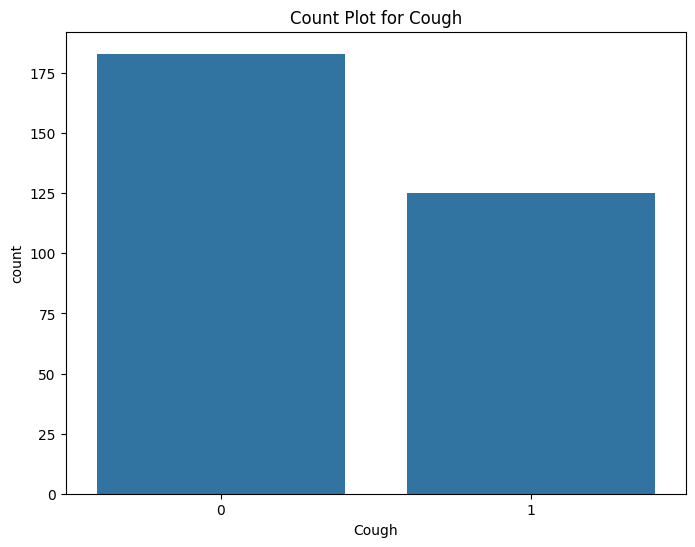

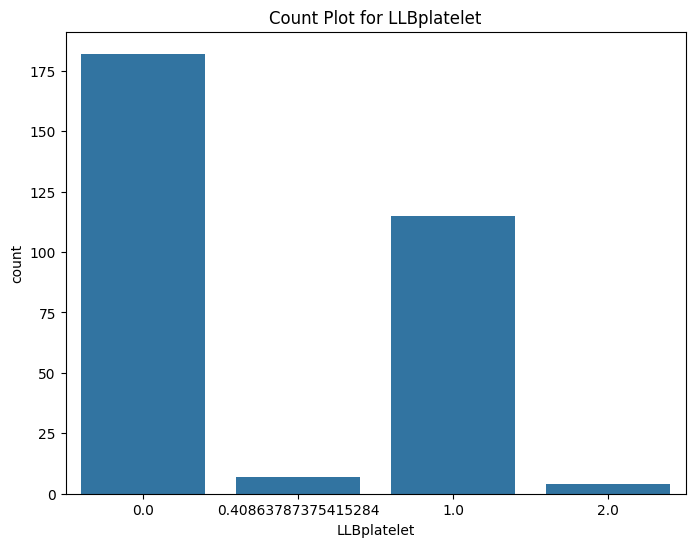

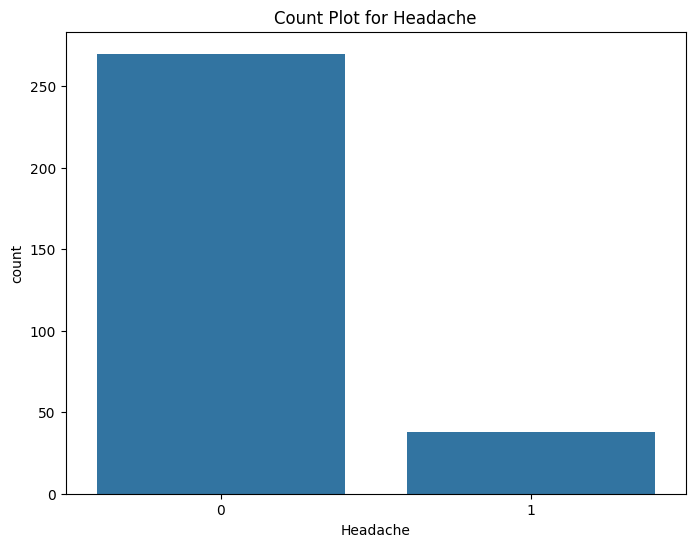

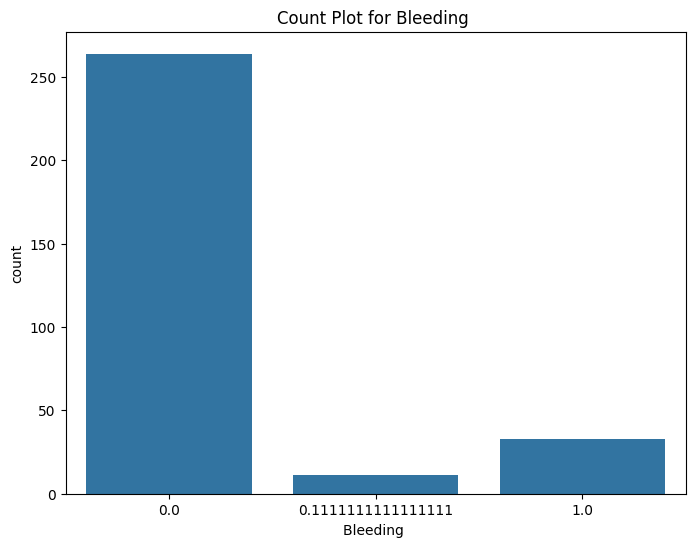

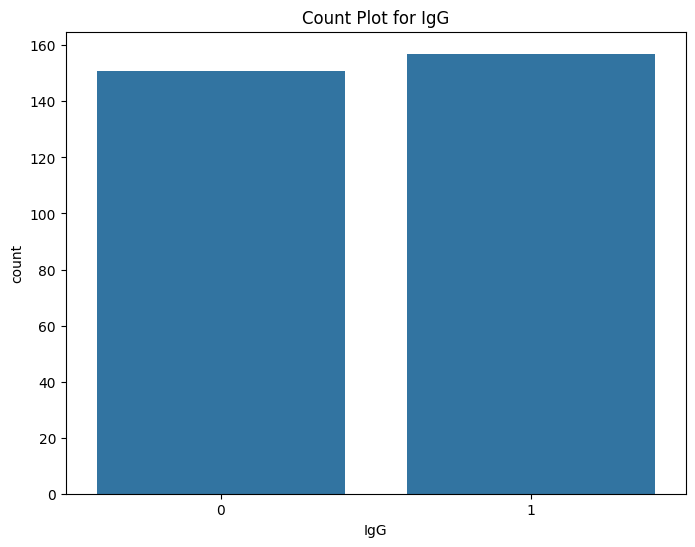

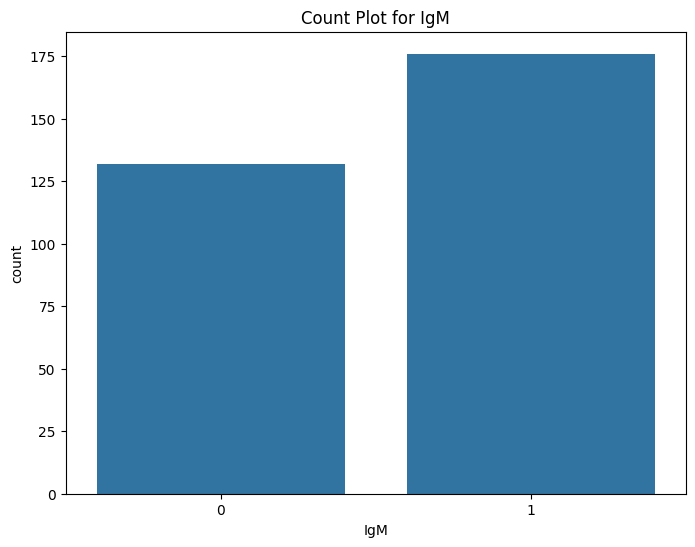

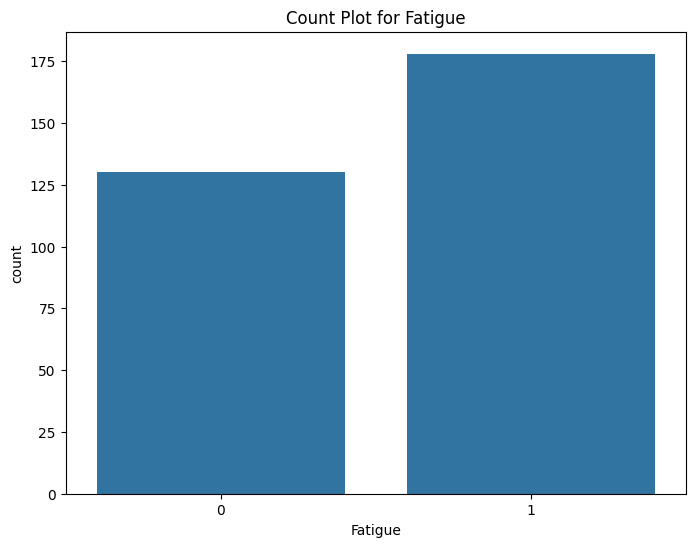

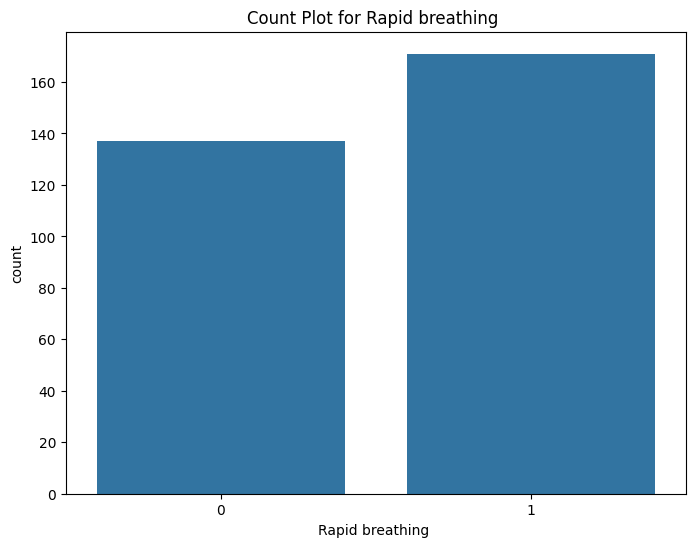

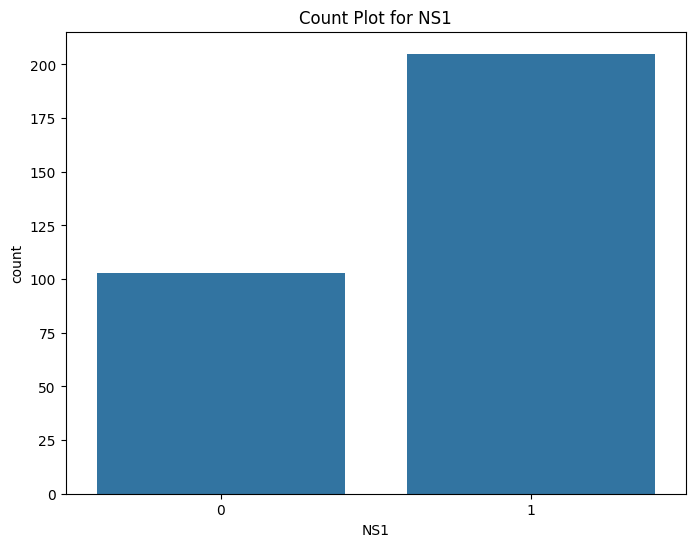

In [ ]:
# Plot the count plots for each feature
for feature in categorical_binary:
    plt.figure(figsize=(8, 6))
    sns.countplot(x=feature, data=dengue_dataset)
    plt.title(f'Count Plot for {feature}')
    plt.show()

**Box plot for categorical non binary value**

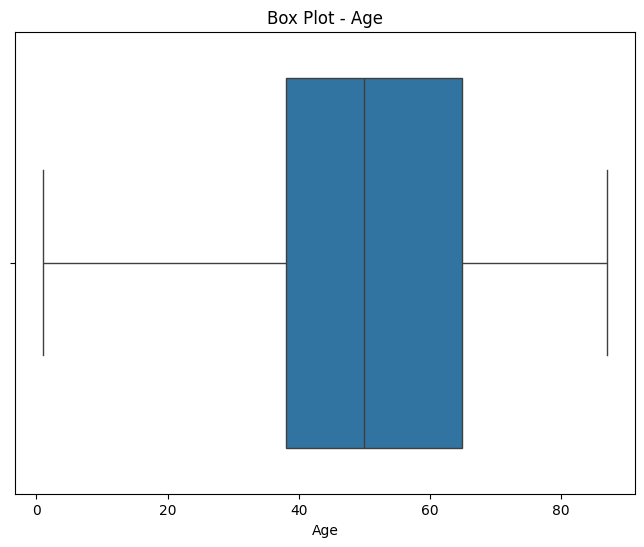

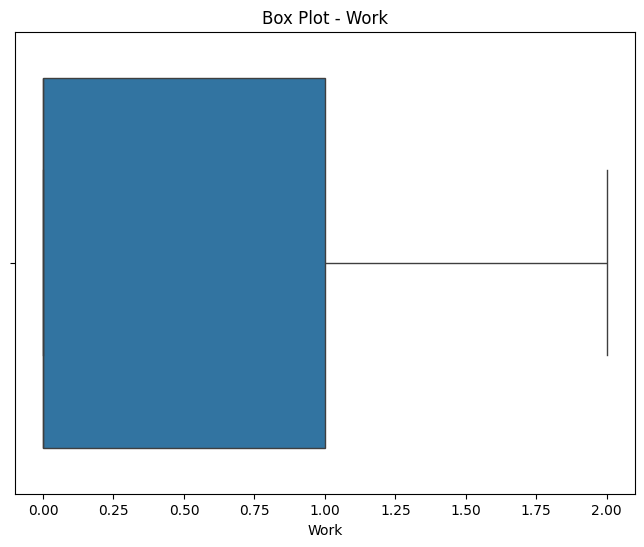

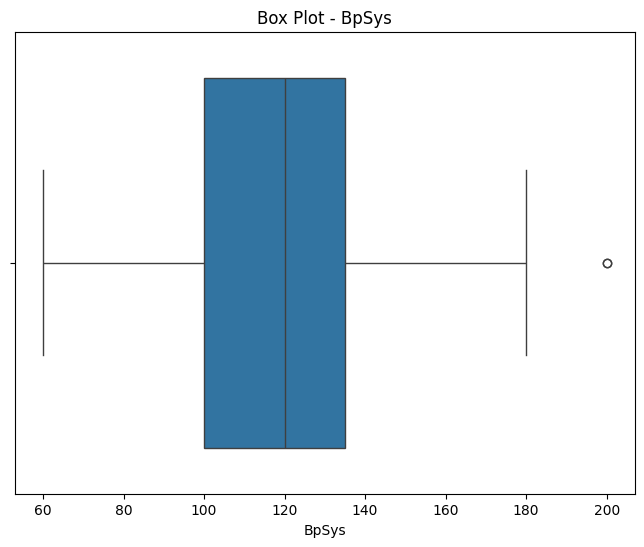

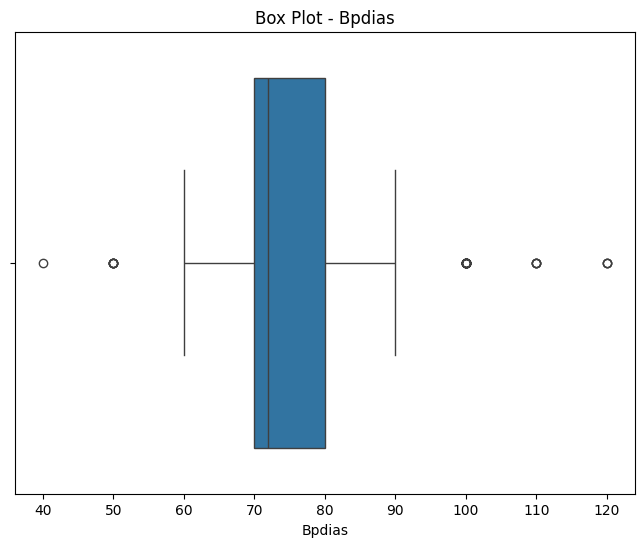

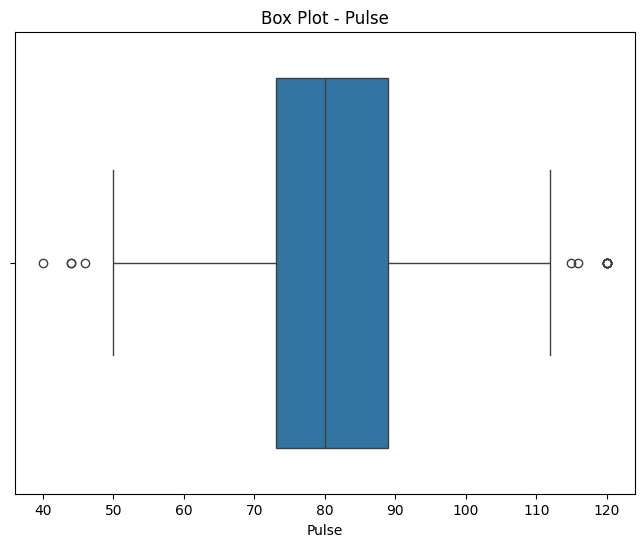

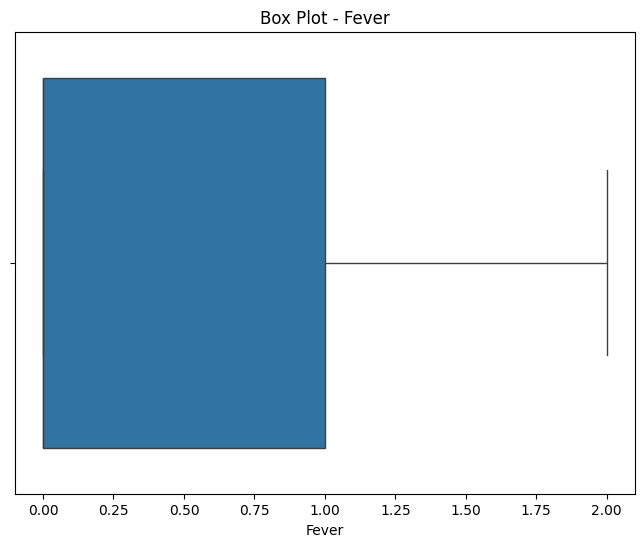

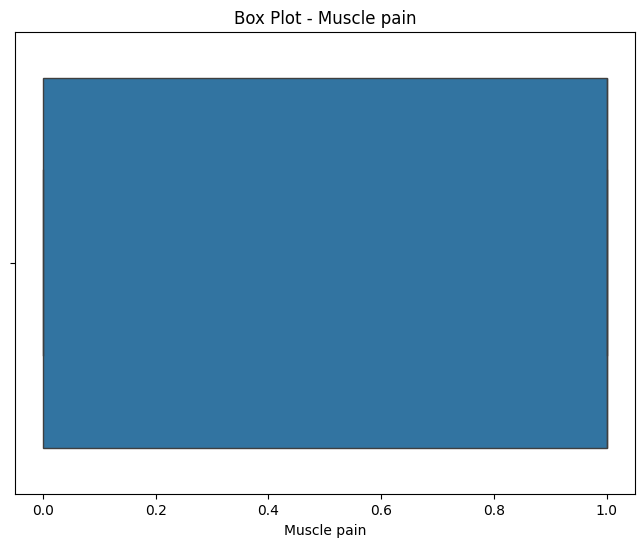

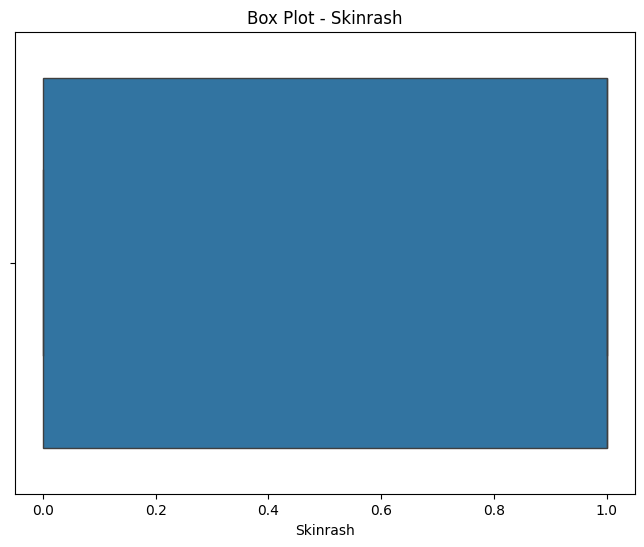

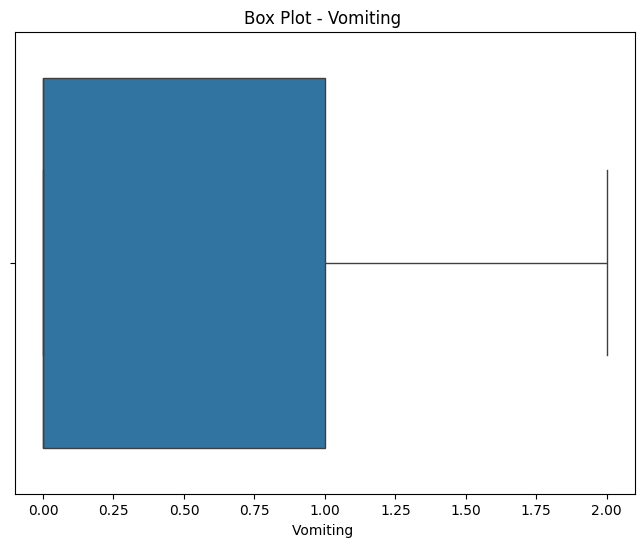

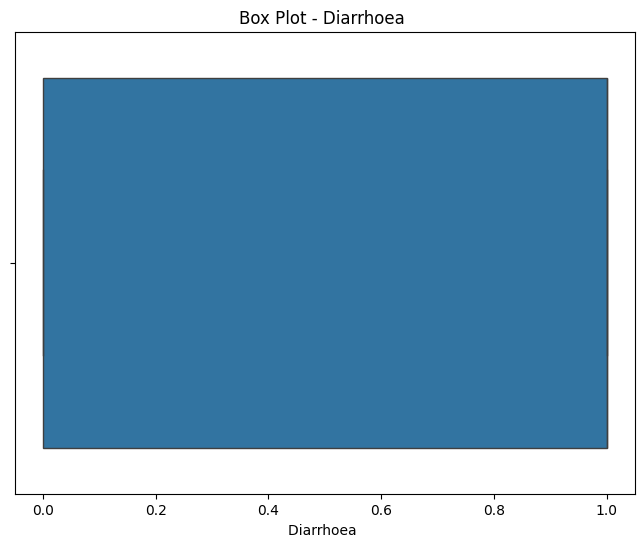

In [ ]:
categorical_non_binary = ['Age','Work', 'BpSys', 'Bpdias','Pulse','Fever','Muscle pain','Skinrash','Vomiting ','Diarrhoea ']

for feature in categorical_non_binary:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=dengue_dataset[feature])  # Change 'column' to 'feature'
    plt.title(f"Box Plot - {feature}")
    plt.show()


**Histograms for All Parameters:**

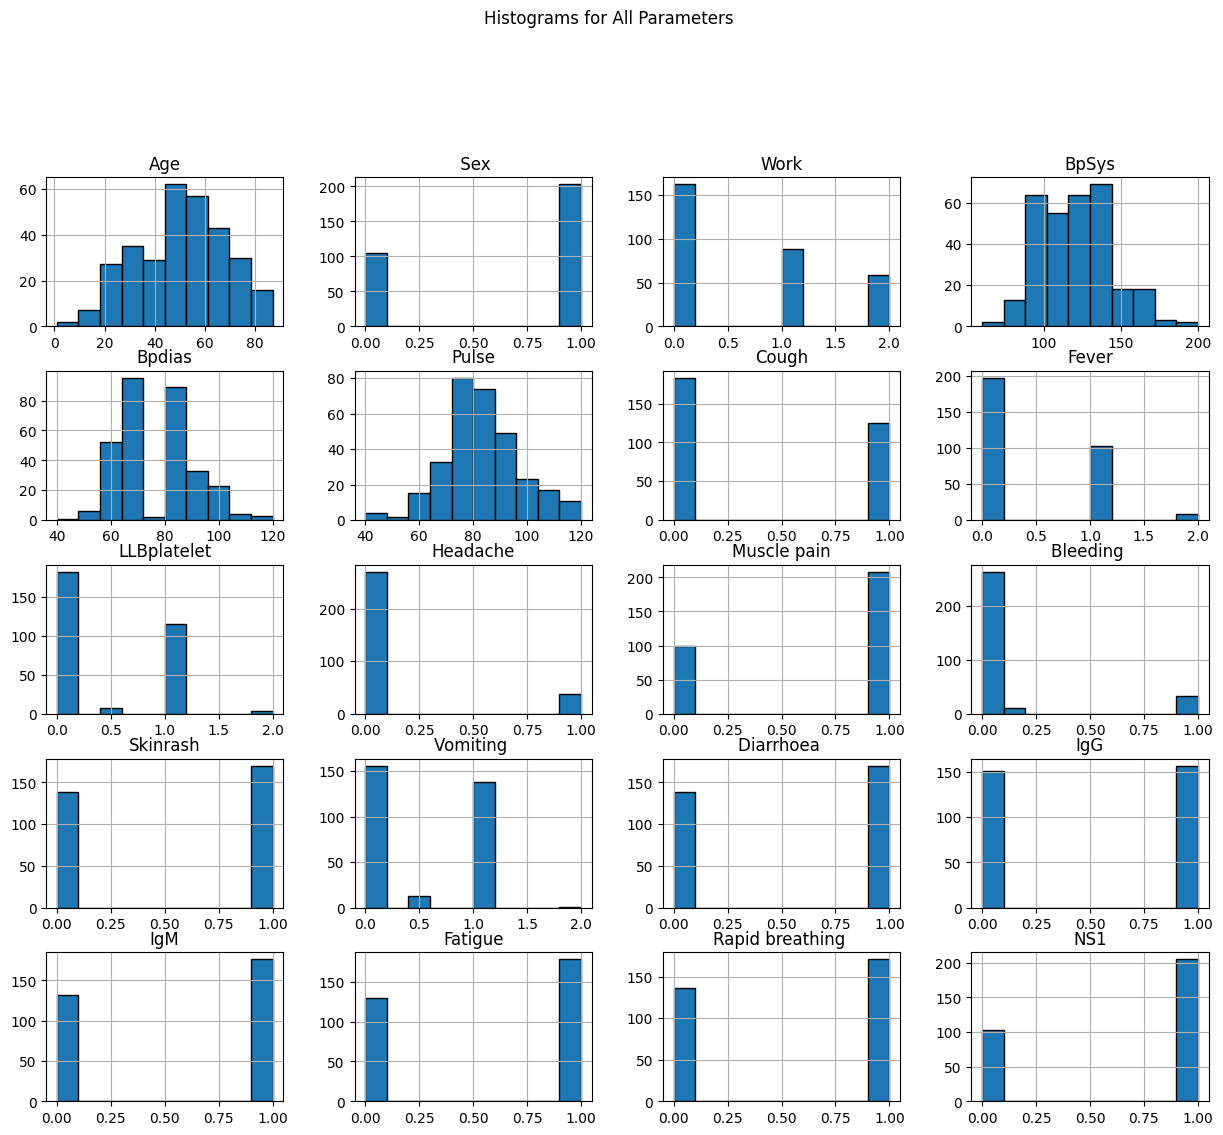

In [ ]:
dengue_dataset.hist(figsize=(15, 12), bins=10,edgecolor='black')
plt.suptitle("Histograms for All Parameters", y=1.02)
plt.show()

In [ ]:
import numpy as np
import pandas as pd


In [ ]:
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
import sklearn
from sklearn import svm

print(sklearn.__version__)


1.2.2


In [ ]:
# Create instances of each model and insert them into a list
models = [
    svm.SVC(kernel='linear'),  # Specify linear kernel here
   #feature extraction of DT
    DecisionTreeClassifier(),
    XGBClassifier(),
    GaussianNB(),
    RandomForestClassifier(),
    KNeighborsClassifier(),
    LogisticRegression(),
    LinearDiscriminantAnalysis()
]

In [ ]:
dengue_dataset.isnull().sum()

Age                 0
 Sex                0
Work                0
BpSys               0
Bpdias              0
Pulse               0
Cough               0
Fever               0
LLBplatelet         0
Headache            0
Muscle pain         0
Bleeding            0
Skinrash            0
Vomiting            0
Diarrhoea           0
IgG                 0
IgM                 0
Fatigue             0
Rapid breathing     0
NS1                 0
dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split

X = dengue_dataset.drop('NS1', axis=1)
y = dengue_dataset['NS1']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
 for model in models:
  model.fit(X_train, y_train)


  y_train_pred = model.predict(X_train)
  y_test_pred = model.predict(X_test)

  train_accuracy = accuracy_score(y_train, y_train_pred)
  train_precision = precision_score(y_train, y_train_pred)
  train_recall = recall_score(y_train, y_train_pred)
  train_f1 = f1_score(y_train, y_train_pred)

  test_accuracy = accuracy_score(y_test, y_test_pred)
  test_precision = precision_score(y_test, y_test_pred)
  test_recall = recall_score(y_test, y_test_pred)
  test_f1 = f1_score(y_test, y_test_pred)

  print(f"-------------------Training Metrics for {model}----------------")
  print(f"Train Accuracy: {train_accuracy:.4f}")
  print(f"Precision: {train_precision:.4f}")
  print(f"Recall: {train_recall:.4f}")
  print(f"F1 Score: {train_f1:.4f}")
  print("\n-------------------Test Metrics-------------------")
  print(f"Test Accuracy: {test_accuracy:.4f}")
  print(f"Precision: {test_precision:.4f}")
  print(f"Recall: {test_recall:.4f}")
  print(f"F1 Score: {test_f1:.4f}")


-------------------Training Metrics for SVC(kernel='linear')----------------
Train Accuracy: 0.9907
Precision: 0.9864
Recall: 1.0000
F1 Score: 0.9932

-------------------Test Metrics-------------------
Test Accuracy: 0.9677
Precision: 0.9831
Recall: 0.9667
F1 Score: 0.9748
-------------------Training Metrics for DecisionTreeClassifier()----------------
Train Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000

-------------------Test Metrics-------------------
Test Accuracy: 0.9677
Precision: 0.9831
Recall: 0.9667
F1 Score: 0.9748
-------------------Training Metrics for XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, 

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


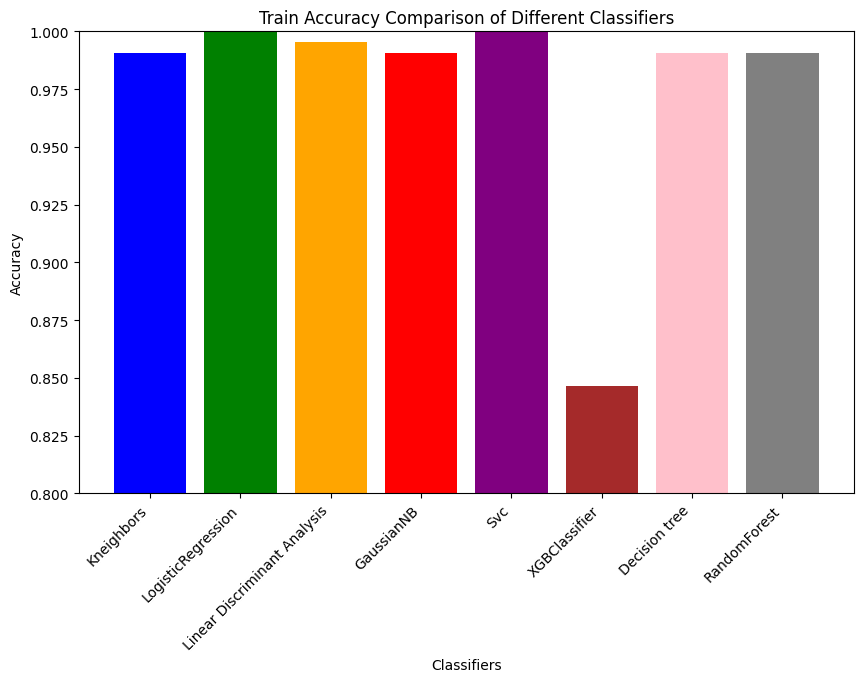

In [ ]:
import matplotlib.pyplot as plt

classifiers = ['Kneighbors', 'LogisticRegression', 'Linear Discriminant Analysis', 'GaussianNB', 'Svc', 'XGBClassifier',  'Decision tree',  'RandomForest']
accuracies = [0.9907, 1.00, 0.9953, 0.9907, 1.00, 0.8465, 0.9907, 0.9907]
colors = ['blue', 'green', 'orange', 'red', 'purple', 'brown', 'pink', 'gray']

plt.figure(figsize=(10, 6))
plt.bar(classifiers, accuracies, color=colors)
plt.xlabel('Classifiers')
plt.ylabel('Accuracy')
plt.title('Train Accuracy Comparison of Different Classifiers')
plt.ylim(0.8, 1.0)
plt.xticks(rotation=45, ha='right')
plt.show()

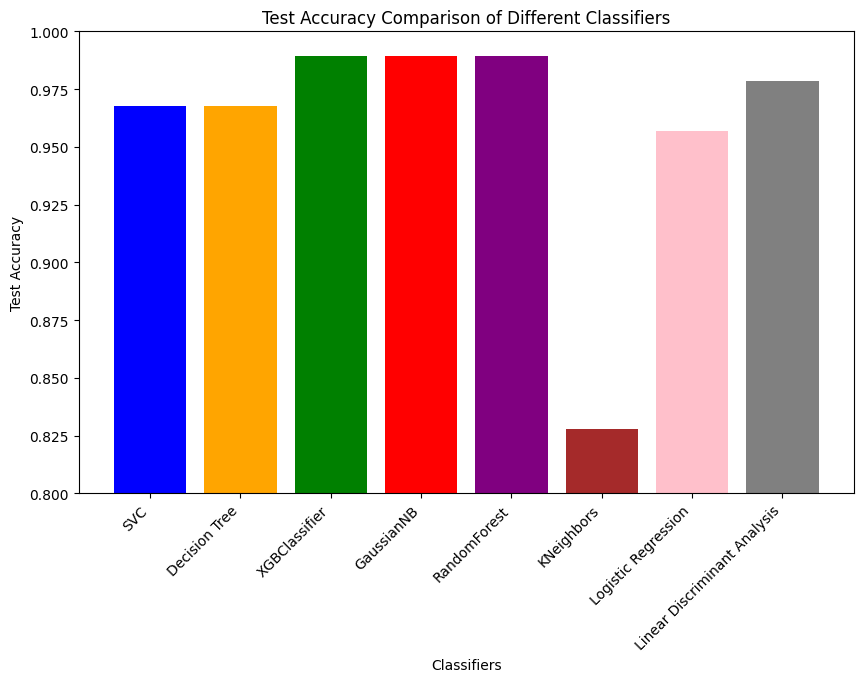

In [ ]:
import matplotlib.pyplot as plt

classifiers = ['SVC', 'Decision Tree', 'XGBClassifier', 'GaussianNB', 'RandomForest', 'KNeighbors', 'Logistic Regression', 'Linear Discriminant Analysis']
accuracies = [0.9677, 0.9677, 0.9892, 0.9892, 0.9892, 0.8280, 0.9570, 0.9785]
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray']

plt.figure(figsize=(10, 6))
bars = plt.bar(classifiers, accuracies, color=colors)
plt.xlabel('Classifiers')
plt.ylabel('Test Accuracy')
plt.title('Test Accuracy Comparison of Different Classifiers')
plt.ylim(0.8, 1.0)
plt.xticks(rotation=45, ha='right')
plt.show()


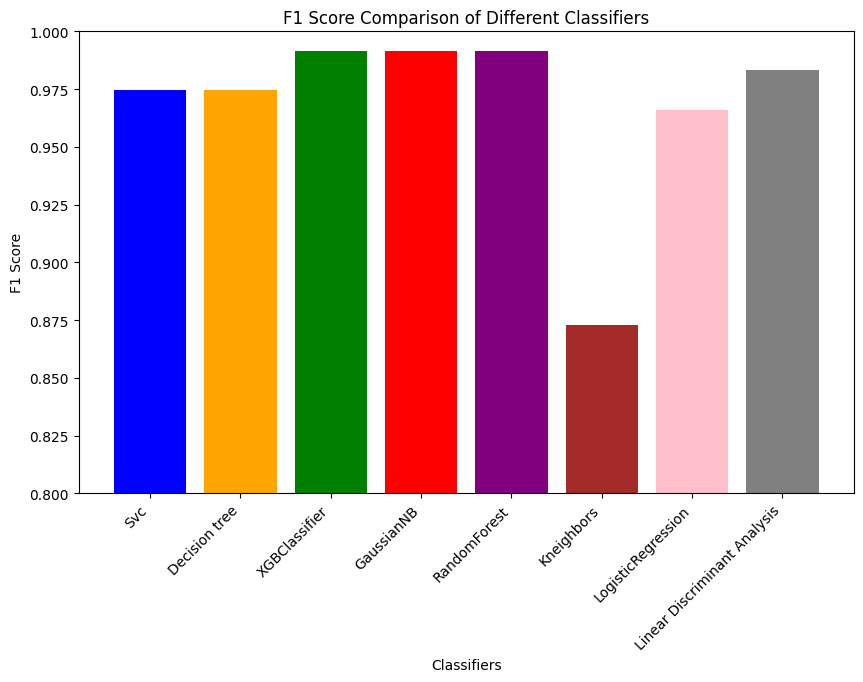

In [ ]:
import matplotlib.pyplot as plt

classifiers = ['Svc', 'Decision tree', 'XGBClassifier', 'GaussianNB', 'RandomForest', 'Kneighbors', 'LogisticRegression', 'Linear Discriminant Analysis']
f1_scores = [0.9748, 0.9748, 0.9917, 0.9917, 0.9917, 0.8730, 0.9661, 0.9833]
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray']

plt.figure(figsize=(10, 6))
plt.bar(classifiers, f1_scores, color=colors)
plt.xlabel('Classifiers')
plt.ylabel('F1 Score')
plt.title('F1 Score Comparison of Different Classifiers')
plt.ylim(0.8, 1.0)
plt.xticks(rotation=45, ha='right')
plt.show()


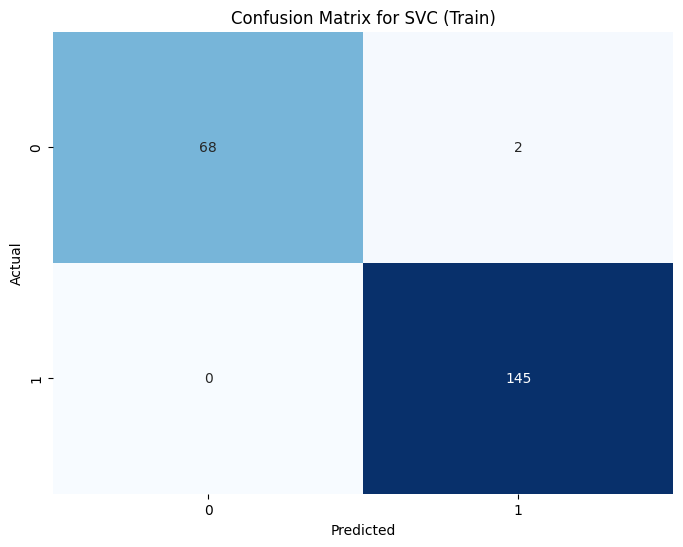

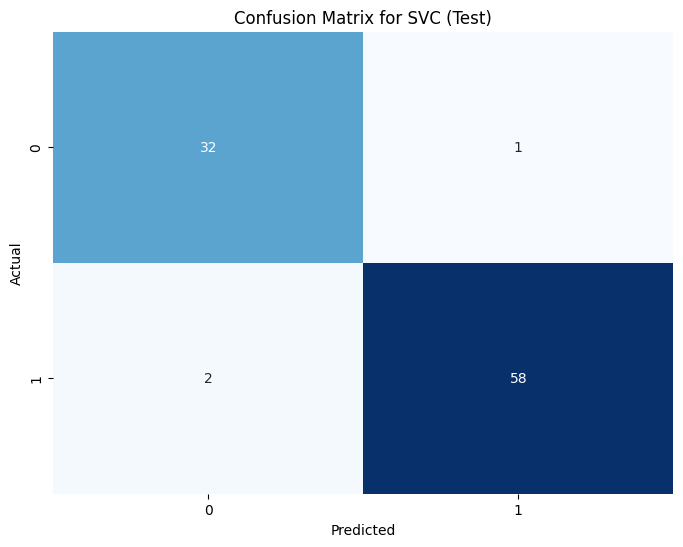

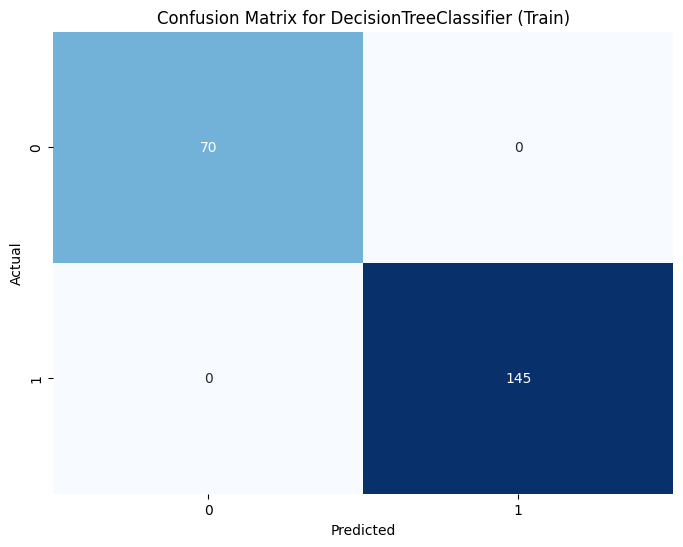

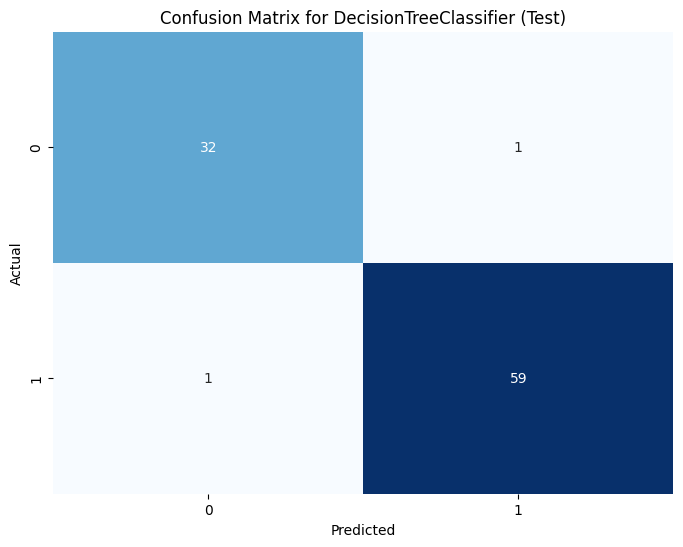

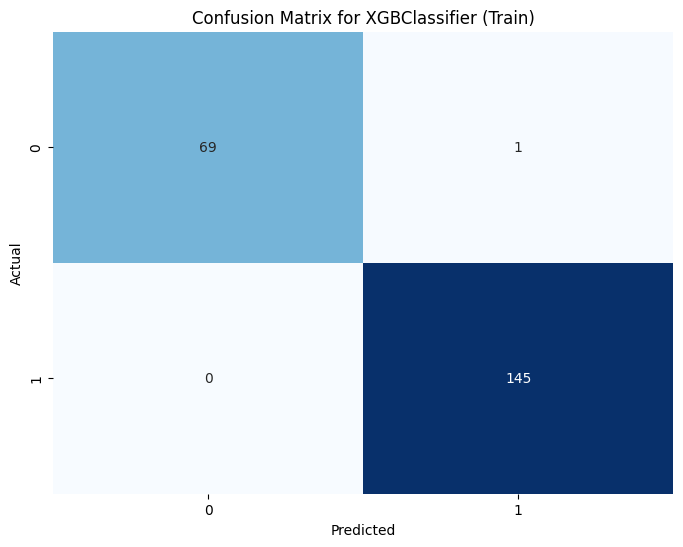

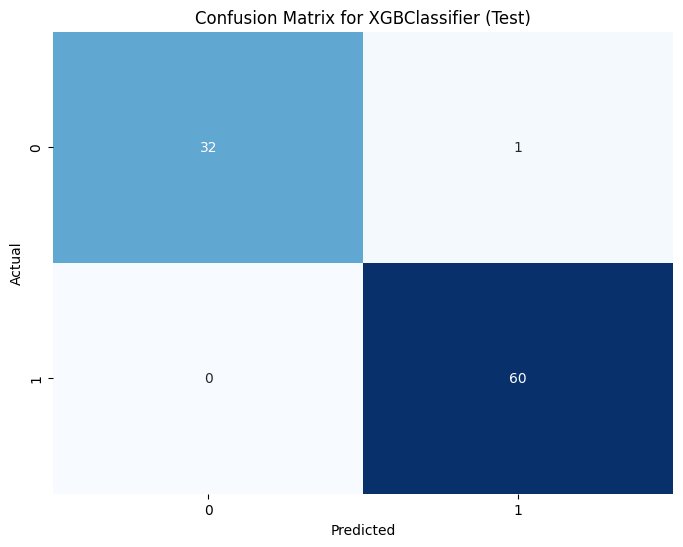

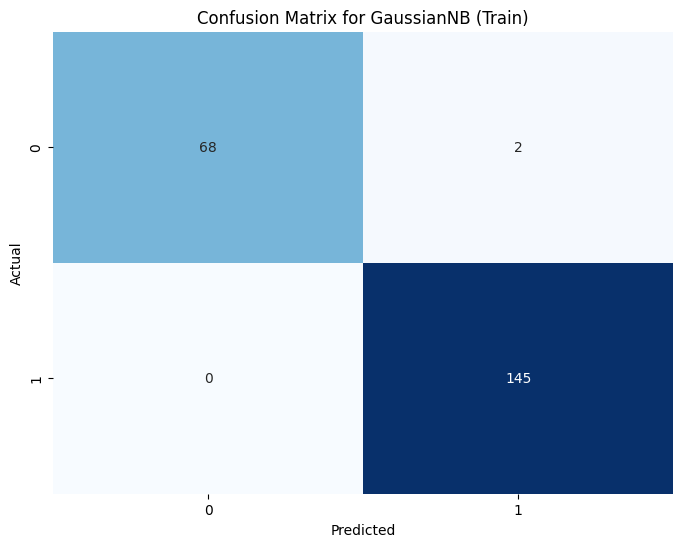

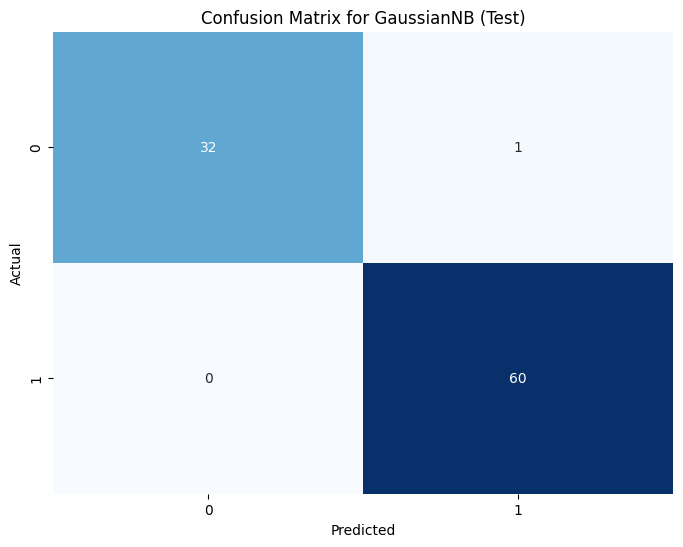

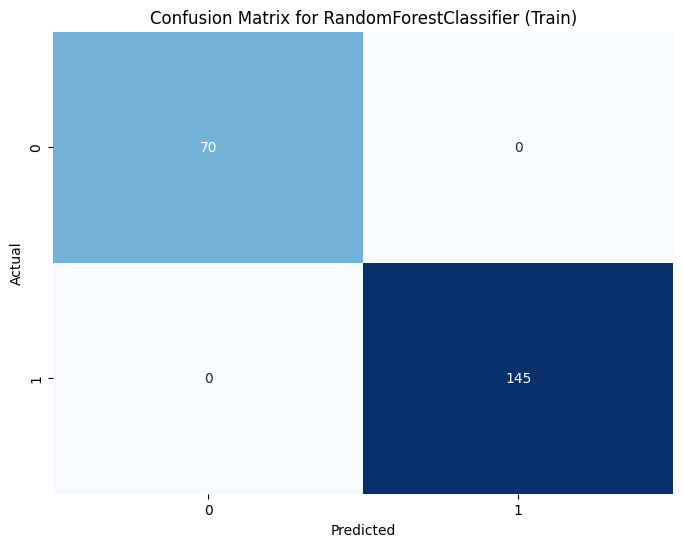

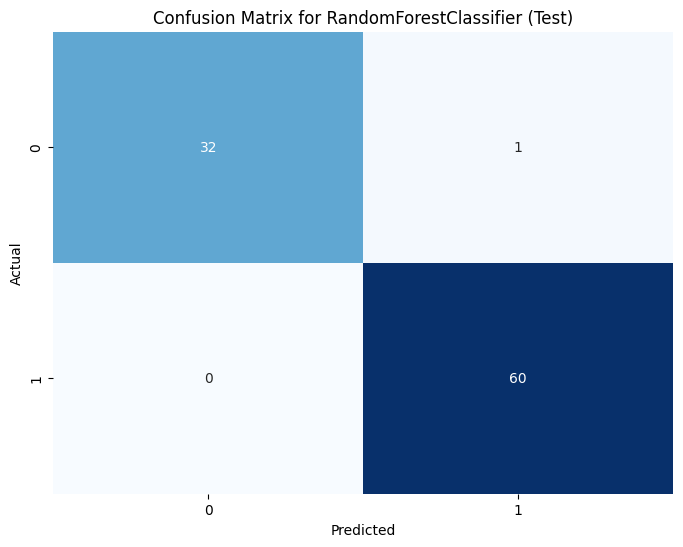

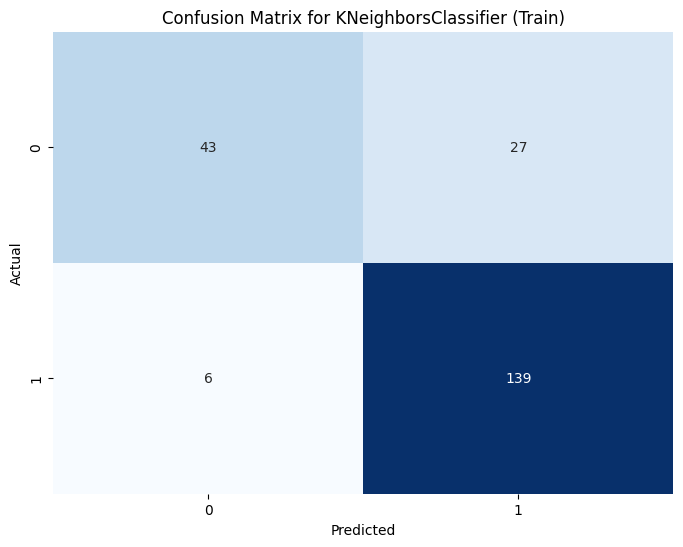

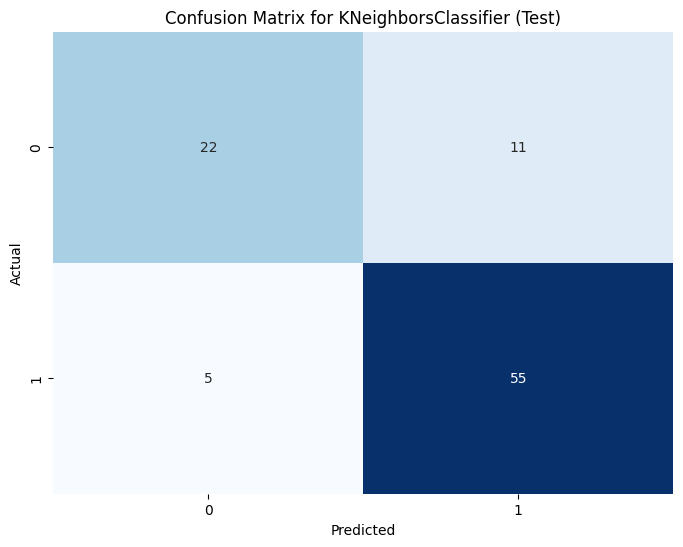

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


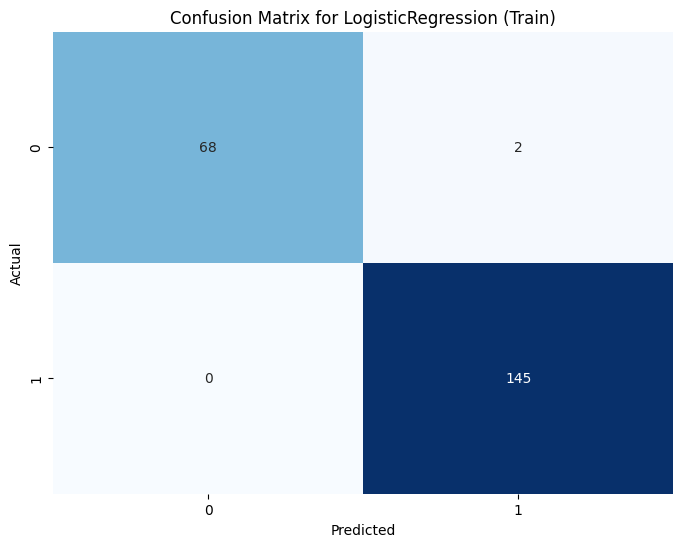

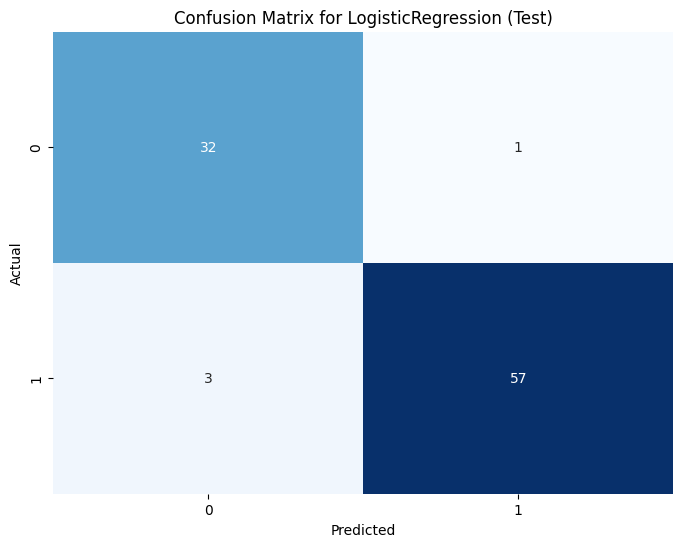

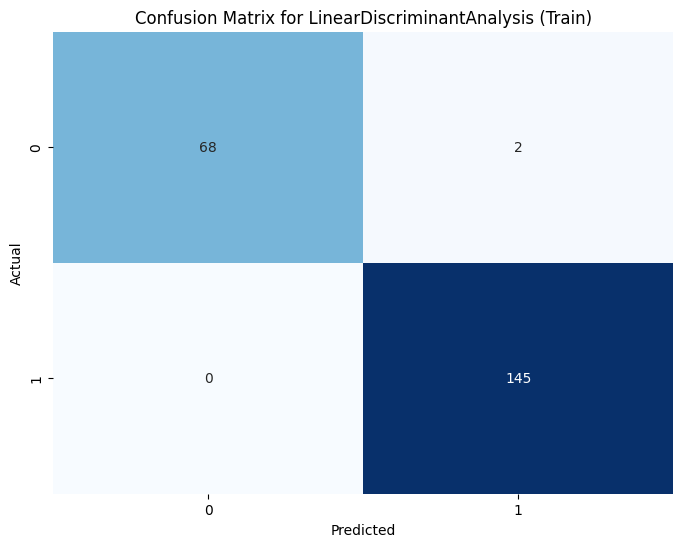

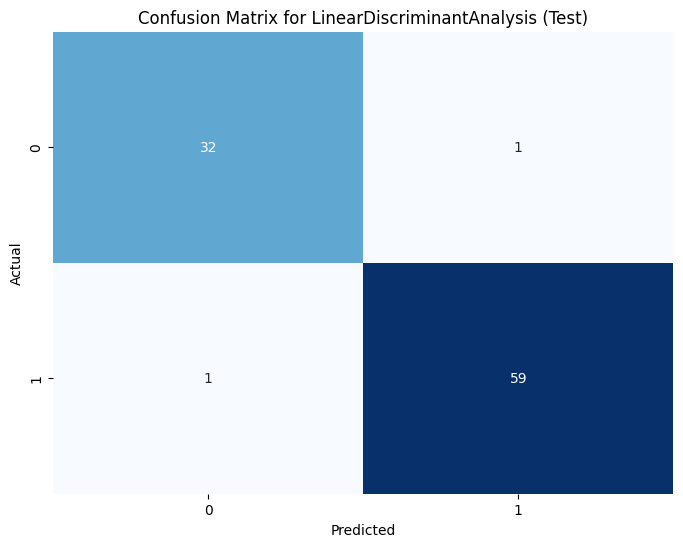

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', cbar=False)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

# Calculate confusion matrices and plot for each model
for model in models:
    # Fit the model
    model.fit(X_train, y_train)

    # Making predictions on the train and test sets
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Plot confusion matrix for train set
    plot_confusion_matrix(y_train, y_train_pred, f'Confusion Matrix for {model.__class__.__name__} (Train)')

    # Plot confusion matrix for test set
    plot_confusion_matrix(y_test, y_test_pred, f'Confusion Matrix for {model.__class__.__name__} (Test)')


In [ ]:
import pickle

In [ ]:
filename = 'trained_model_main.sav'
pickle.dump(models, open(filename, 'wb'))

In [ ]:
loaded_model = pickle.load(open('trained_model_main.sav', 'rb'))

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


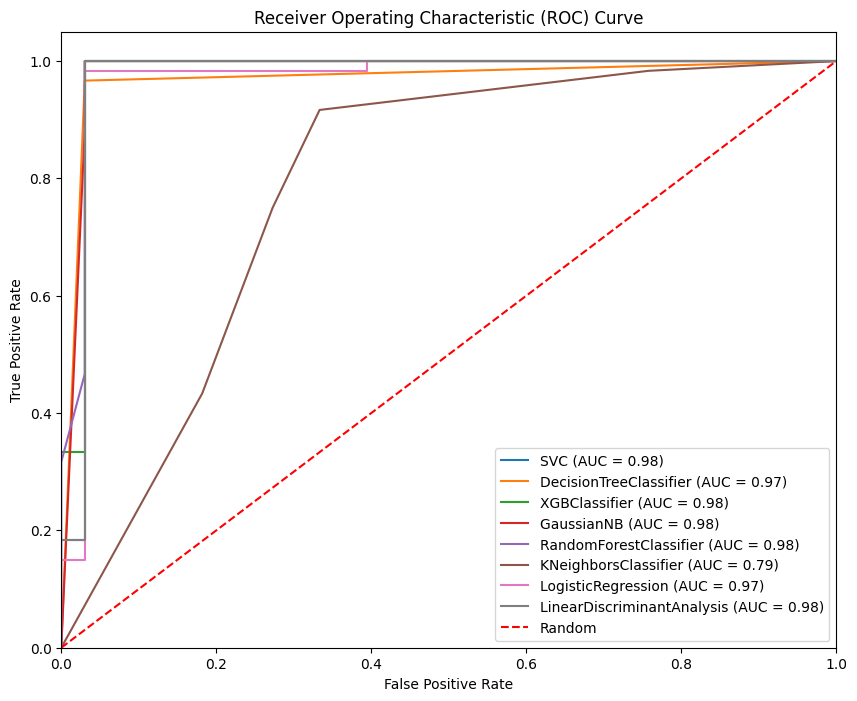

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
models = [
    svm.SVC(kernel='linear', probability=True),
    DecisionTreeClassifier(),
    XGBClassifier(),
    GaussianNB(),
    RandomForestClassifier(),
    KNeighborsClassifier(),
    LogisticRegression(),
    LinearDiscriminantAnalysis()
]


probas = [model.fit(X_train, y_train).predict_proba(X_test)[:, 1] for model in models]
p

plt.figure(figsize=(10, 8))
for i, model in enumerate(models):
    fpr, tpr, _ = roc_curve(y_test, probas[i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model.__class__.__name__} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='r', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


In [ ]:
from sklearn.metrics import roc_auc_score

auc_scores = {}
for model in models:
    model.fit(X_train, y_train)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    auc_scores[model.__class__.__name__] = roc_auc

# Print AUC scores
for model_name, auc_score in auc_scores.items():
    print(f"{model_name}: AUC = {auc_score:.2f}")


SVC: AUC = 0.98
DecisionTreeClassifier: AUC = 0.98
XGBClassifier: AUC = 0.98
GaussianNB: AUC = 0.98
RandomForestClassifier: AUC = 0.98
KNeighborsClassifier: AUC = 0.79
LogisticRegression: AUC = 0.97
LinearDiscriminantAnalysis: AUC = 0.98


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:778: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_scorer.py", line 373, in _score
    y_pred = method_caller(clf, "decision_function", X)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_scorer.py", line 73, in _cached_call
    return getattr(estimator, method)(*args, **kwargs)
AttributeError: 'DecisionTreeClassifier' object has no attribute 'decision_function'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 767, in _score
    scores = scorer(estimator, X_test, y_test)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_scorer.py", line 234, in __call__
    ret

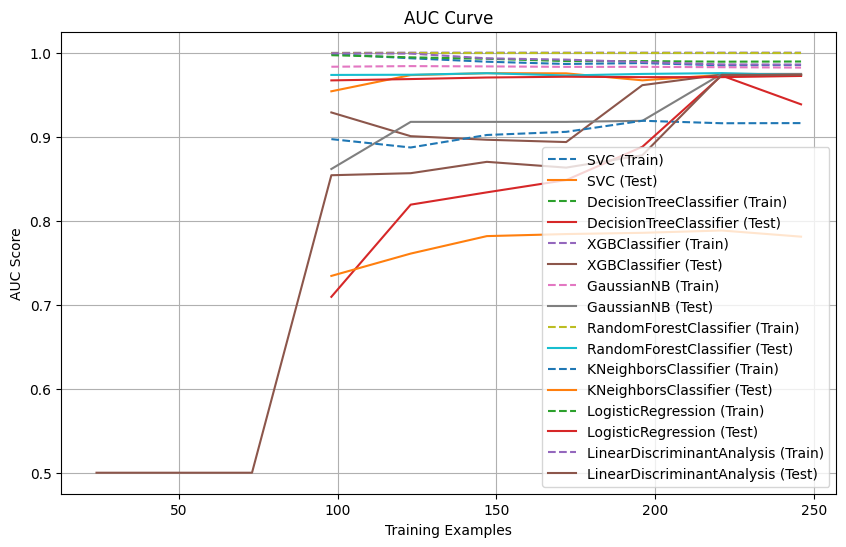

In [ ]:
import numpy as np
from sklearn.model_selection import learning_curve

# Define different training set sizes (you can adjust this as needed)
train_sizes = np.linspace(0.1, 1.0, 10)

# Initialize lists to store training and test AUC scores for each model
train_auc_scores = []
test_auc_scores = []

# Calculate AUC scores for different training set sizes
for model in models:
    train_sizes, train_auc, test_auc = learning_curve(model, X, y, cv=5, train_sizes=train_sizes, scoring='roc_auc')
    train_auc_scores.append(np.mean(train_auc, axis=1))
    test_auc_scores.append(np.mean(test_auc, axis=1))

# Plot AUC curve
plt.figure(figsize=(10, 6))
for i, model_name in enumerate([model.__class__.__name__ for model in models]):
    plt.plot(train_sizes, train_auc_scores[i], label=f'{model_name} (Train)', linestyle='--')
    plt.plot(train_sizes, test_auc_scores[i], label=f'{model_name} (Test)')

plt.title('AUC Curve')
plt.xlabel('Training Examples')
plt.ylabel('AUC Score')
plt.legend()
plt.grid(True)
plt.show()


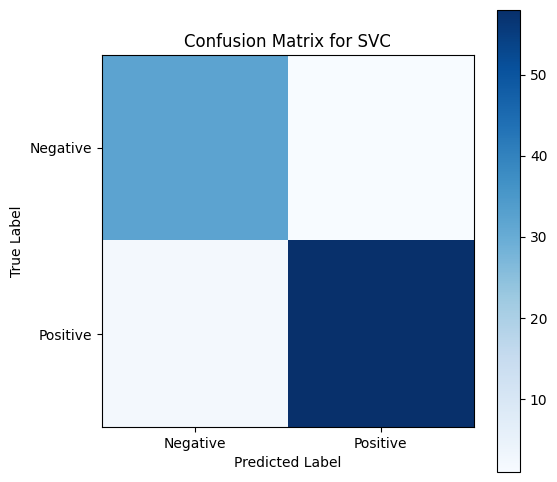

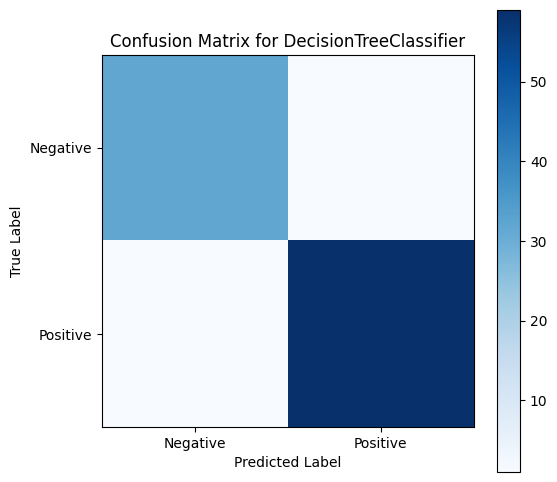

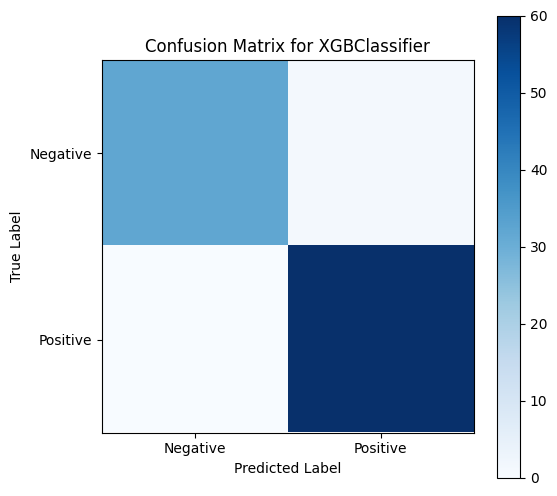

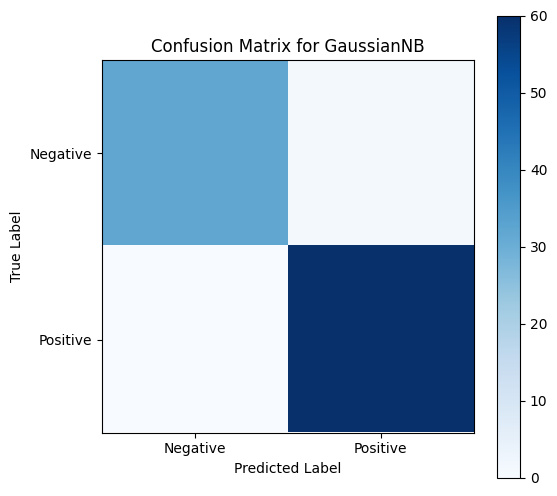

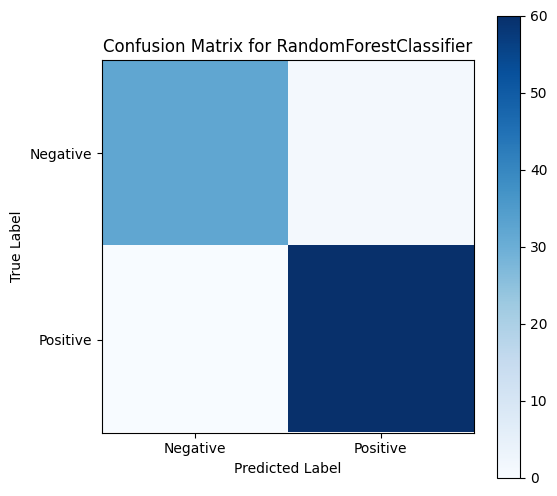

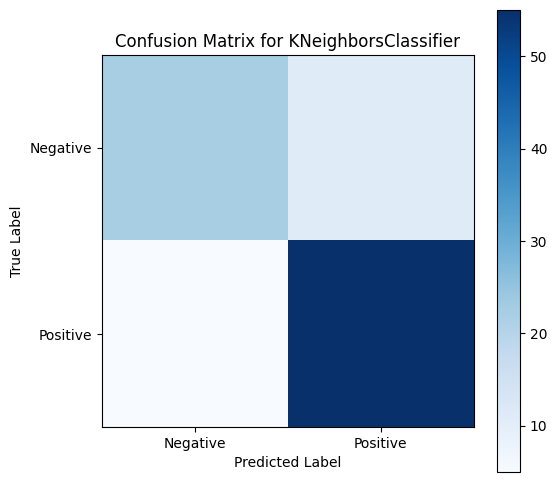

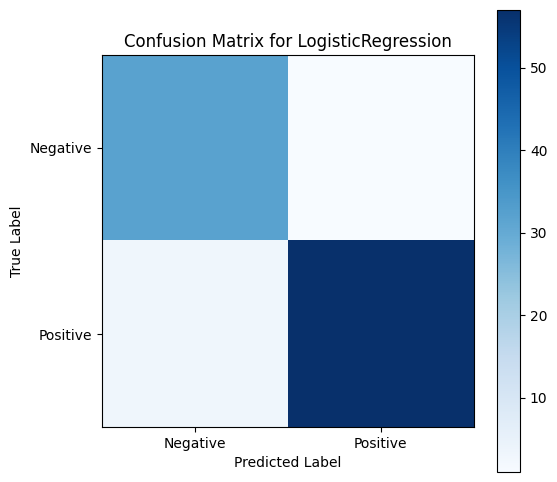

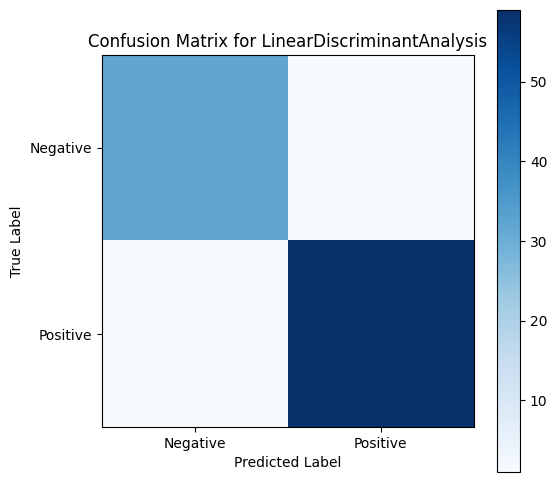

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Assuming 'models' has trained models and X_test, y_test are test data

# Create an empty confusion matrix
confusion_matrices = []
for model in models:
  y_pred = model.predict(X_test)
  confusion_matrix_values = confusion_matrix(y_test, y_pred)
  confusion_matrices.append(confusion_matrix_values)

# Plot the confusion matrices for each model
for i, model_name in enumerate([model.__class__.__name__ for model in models]):
  plt.figure(figsize=(6, 6))
  plt.imshow(confusion_matrices[i], cmap='Blues')
  plt.colorbar()
  plt.title(f'Confusion Matrix for {model_name}')
  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')
  plt.xticks([0, 1], ['Negative', 'Positive'])
  plt.yticks([0, 1], ['Negative', 'Positive'])
  plt.show()



In [ ]:
import pandas as pd

# Initialize lists to store evaluation metrics for each model
model_names = []
train_accuracy_list = []
train_precision_list = []
train_recall_list = []
train_f1_list = []
test_accuracy_list = []
test_precision_list = []
test_recall_list = []
test_f1_list = []

# Calculate evaluation metrics for each model
for model in models:
    model_names.append(model.__class__.__name__)

    # Fit the model
    model.fit(X_train, y_train)

    # Making predictions on the train and test sets
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate metrics on the training set
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred)
    train_recall = recall_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)

    # Calculate metrics on the test set
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)

    # Append metrics to the respective lists
    train_accuracy_list.append(train_accuracy)
    train_precision_list.append(train_precision)
    train_recall_list.append(train_recall)
    train_f1_list.append(train_f1)
    test_accuracy_list.append(test_accuracy)
    test_precision_list.append(test_precision)
    test_recall_list.append(test_recall)
    test_f1_list.append(test_f1)

# Create a DataFrame to store the evaluation metrics
metrics_df = pd.DataFrame({
    'Model': model_names,
    'Train Accuracy': train_accuracy_list,
    'Train Precision': train_precision_list,
    'Train Recall': train_recall_list,
    'Train F1 Score': train_f1_list,
    'Test Accuracy': test_accuracy_list,
    'Test Precision': test_precision_list,
    'Test Recall': test_recall_list,
    'Test F1 Score': test_f1_list
})

# Display the DataFrame
print(metrics_df)


                        Model  Train Accuracy  Train Precision  Train Recall  \
0                         SVC        0.990698         0.986395      1.000000   
1      DecisionTreeClassifier        1.000000         1.000000      1.000000   
2               XGBClassifier        0.995349         0.993151      1.000000   
3                  GaussianNB        0.990698         0.986395      1.000000   
4      RandomForestClassifier        1.000000         1.000000      1.000000   
5        KNeighborsClassifier        0.846512         0.837349      0.958621   
6          LogisticRegression        0.990698         0.986395      1.000000   
7  LinearDiscriminantAnalysis        0.990698         0.986395      1.000000   

   Train F1 Score  Test Accuracy  Test Precision  Test Recall  Test F1 Score  
0        0.993151       0.967742        0.983051     0.966667       0.974790  
1        1.000000       0.967742        0.983051     0.966667       0.974790  
2        0.996564       0.989247        0.

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


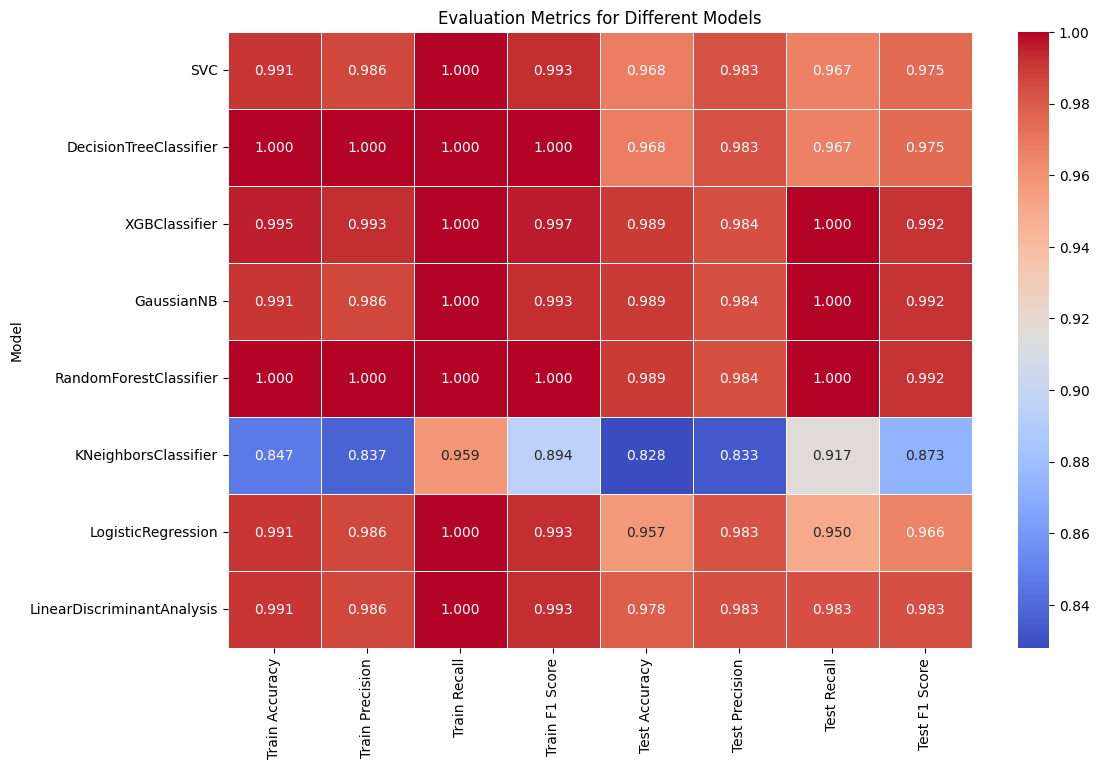

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a DataFrame to store the evaluation metrics
metrics_df = pd.DataFrame({
    'Model': model_names,
    'Train Accuracy': train_accuracy_list,
    'Train Precision': train_precision_list,
    'Train Recall': train_recall_list,
    'Train F1 Score': train_f1_list,
    'Test Accuracy': test_accuracy_list,
    'Test Precision': test_precision_list,
    'Test Recall': test_recall_list,
    'Test F1 Score': test_f1_list
})

# Set the 'Model' column as the index
metrics_df.set_index('Model', inplace=True)

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(metrics_df, annot=True, cmap='coolwarm', fmt=".3f", linewidths=.5)
plt.title('Evaluation Metrics for Different Models')
plt.show()


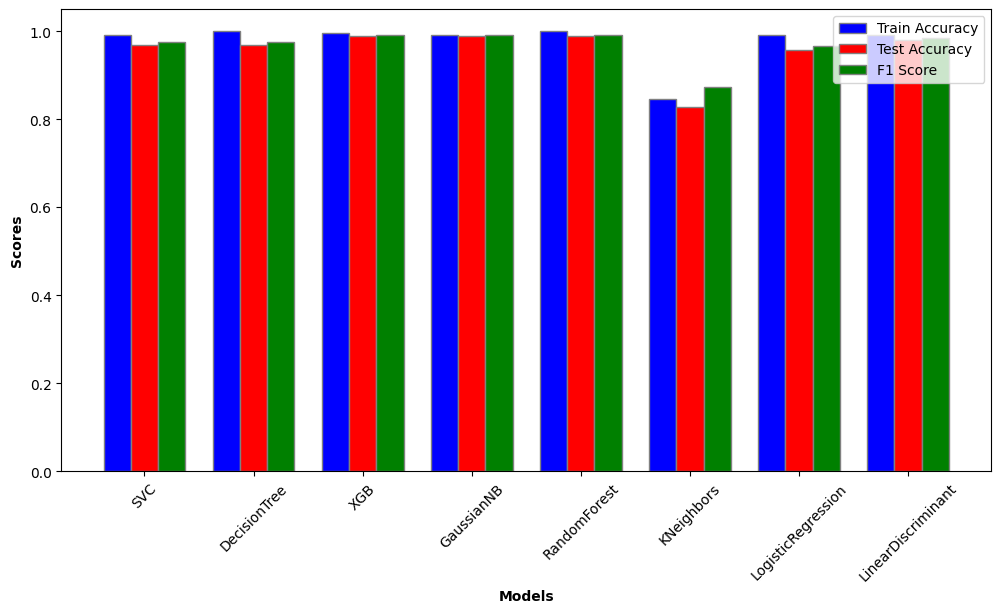

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['SVC', 'DecisionTree', 'XGB', 'GaussianNB', 'RandomForest', 'KNeighbors', 'LogisticRegression', 'LinearDiscriminant']
train_accuracy = [0.9907, 1.0000, 0.9953, 0.9907, 1.0000, 0.8465, 0.9907, 0.9907]
test_accuracy = [0.9677, 0.9677, 0.9892, 0.9892, 0.9892, 0.8280, 0.9570, 0.9785]
f1_score = [0.9748, 0.9748, 0.9917, 0.9917, 0.9917, 0.8730, 0.9661, 0.9833]

# Set width of bar
barWidth = 0.25

# Set position of bar on X axis
r1 = np.arange(len(train_accuracy))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]

# Make the plot
plt.figure(figsize=(12, 6))
plt.bar(r1, train_accuracy, color='blue', width=barWidth, edgecolor='grey', label='Train Accuracy')
plt.bar(r2, test_accuracy, color='red', width=barWidth, edgecolor='grey', label='Test Accuracy')
plt.bar(r3, f1_score, color='green', width=barWidth, edgecolor='grey', label='F1 Score')

# Add xticks on the middle of the group bars
plt.xlabel('Models', fontweight='bold')
plt.xticks([r + barWidth for r in range(len(train_accuracy))], models, rotation=45)

# Add ylabel
plt.ylabel('Scores', fontweight='bold')

# Add legend
plt.legend()

# Show plot
plt.show()


In [ ]:
import pandas as pd

# Data
data = {
    'Model': models,
    'Train Accuracy': train_accuracy,
    'Test Accuracy': test_accuracy,
    'F1 Score': f1_score
}

# Create DataFrame
df = pd.DataFrame(data)

# Display the DataFrame
print(df.to_string(index=False))


             Model  Train Accuracy  Test Accuracy  F1 Score
               SVC          0.9907         0.9677    0.9748
      DecisionTree          1.0000         0.9677    0.9748
               XGB          0.9953         0.9892    0.9917
        GaussianNB          0.9907         0.9892    0.9917
      RandomForest          1.0000         0.9892    0.9917
        KNeighbors          0.8465         0.8280    0.8730
LogisticRegression          0.9907         0.9570    0.9661
LinearDiscriminant          0.9907         0.9785    0.9833
